# 02 · Exploratory Data Analysis

**Phase 2 of the project plan.**

Building on `01_data_understanding.ipynb`, this notebook digs into data quality, sensor variance, distributions, degradation trajectories, smoothing, correlation with RUL, outliers, and operating-condition effects — everything needed to make informed feature-engineering decisions in `03_feature_engineering.ipynb`.


In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import data_loader as dl
from src import preprocessing as pp

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 4)
pd.set_option("display.max_columns", 40)

INTERIM_DIR = "../data/interim"
SUBSET = "FD001"

train = pd.read_parquet(f"{INTERIM_DIR}/train_{SUBSET}_with_rul.parquet")
train.shape


(20631, 27)

## Step 2.1 — Data quality

Basic sanity checks before anything else: missing values, duplicate rows, infinities, dtypes.


In [2]:
quality = pd.DataFrame({
    "dtype": train.dtypes,
    "n_missing": train.isna().sum(),
    "n_inf": np.isinf(train.select_dtypes(include=[np.number])).sum().reindex(train.columns, fill_value=0),
    "n_unique": train.nunique(),
})
print("Duplicate rows:", train.duplicated().sum())
quality


Duplicate rows: 0


,dtype,n_missing,n_inf,n_unique
unit_number,int64,0,0,100
cycle,int64,0,0,362
op_setting_1,float64,0,0,158
op_setting_2,float64,0,0,13
op_setting_3,float64,0,0,1
sensor_1,float64,0,0,1
sensor_2,float64,0,0,310
sensor_3,float64,0,0,3012
sensor_4,float64,0,0,4051
sensor_5,float64,0,0,1


## Step 2.2 — Sensor variance triage

Some sensors in C-MAPSS are known to be flat (the simulator drives them to a fixed setpoint regardless of degradation). `src/preprocessing.classify_sensor_variance` buckets each sensor into `constant` / `near_constant` / `variable` — a `constant` sensor carries zero information and is a safe drop; `near_constant` is a judgment call we make explicitly (and revisit) in the next notebook.


In [3]:
variance_report = pp.classify_sensor_variance(train, dl.SENSOR_COLS)
variance_report.sort_values("normalized_std")


,n_unique,std,normalized_std,min,max,category
sensor,,,,,,
sensor_1,1,0.000000e+00,0.000000e+00,518.6700,518.6700,constant
sensor_10,1,0.000000e+00,0.000000e+00,1.3000,1.3000,constant
sensor_19,1,0.000000e+00,0.000000e+00,100.0000,100.0000,constant
sensor_18,1,0.000000e+00,0.000000e+00,2388.0000,2388.0000,constant
sensor_16,1,3.469531e-18,1.156510e-16,0.0300,0.0300,constant
sensor_5,1,5.329200e-15,3.645143e-16,14.6200,14.6200,constant
sensor_8,53,7.098548e-02,2.972471e-05,2387.9000,2388.5600,near_constant
sensor_13,56,7.191892e-02,3.011559e-05,2387.8800,2388.5600,near_constant
sensor_6,2,1.388985e-03,6.427569e-05,21.6000,21.6100,near_constant


In [4]:
print(variance_report["category"].value_counts())
constant_sensors = variance_report[variance_report["category"] == "constant"].index.tolist()
near_constant_sensors = variance_report[variance_report["category"] == "near_constant"].index.tolist()
variable_sensors = variance_report[variance_report["category"] == "variable"].index.tolist()
print("constant:", constant_sensors)
print("near_constant:", near_constant_sensors)
print("variable:", variable_sensors)


category
variable         11
constant          6
near_constant     4
Name: count, dtype: int64
constant: ['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
near_constant: ['sensor_2', 'sensor_6', 'sensor_8', 'sensor_13']
variable: ['sensor_3', 'sensor_4', 'sensor_7', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


## Step 2.3 — Sensor distributions

Histograms for every *variable* sensor (constant ones would just be a spike and add no insight here).


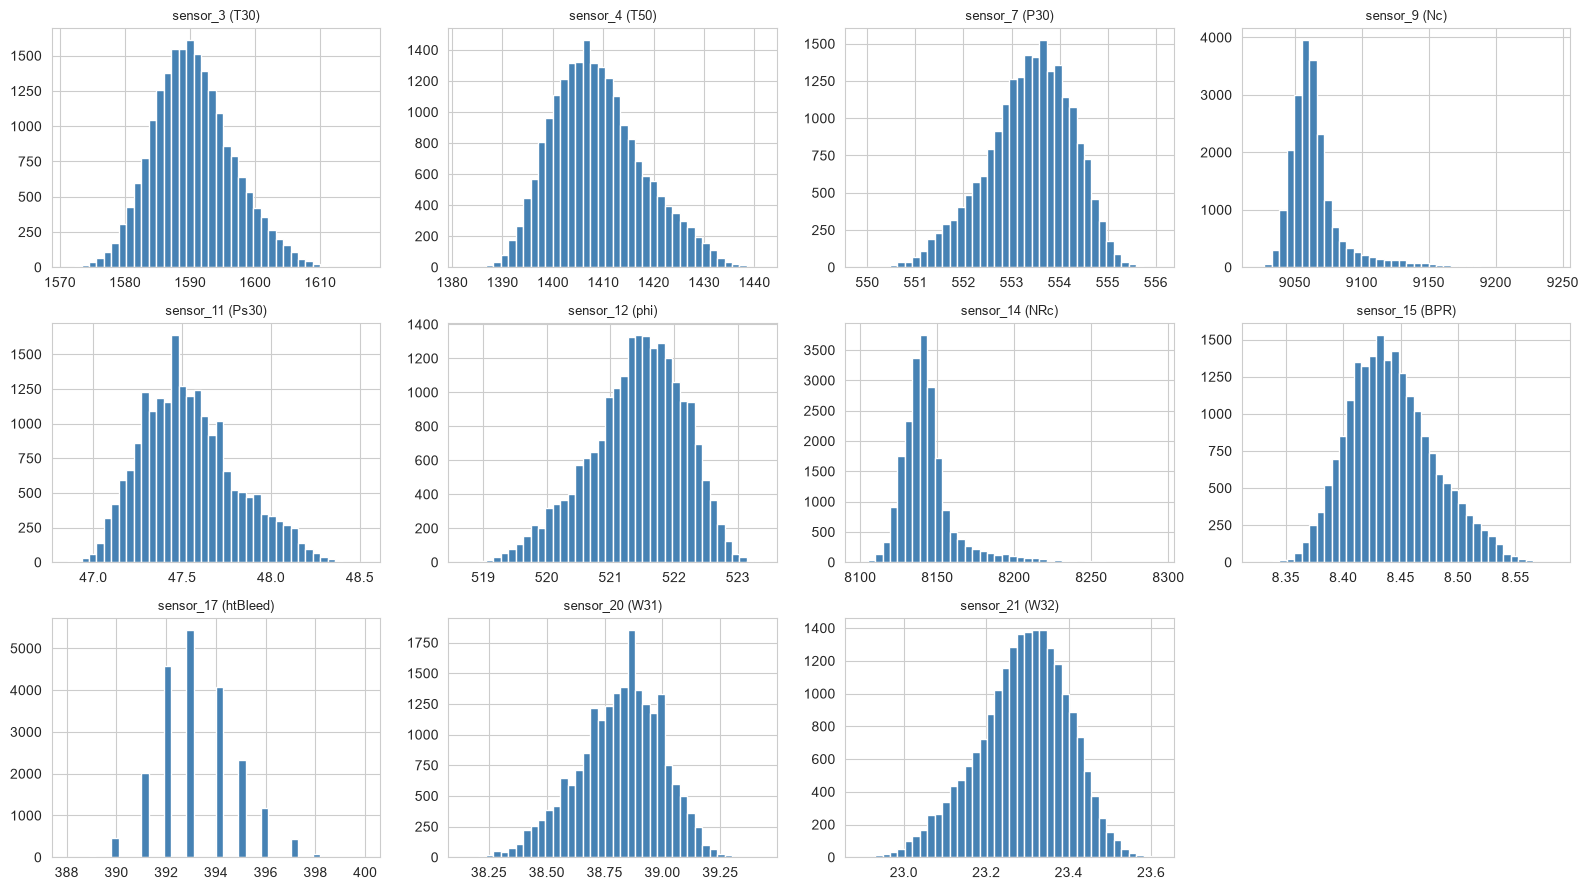

In [5]:
n = len(variable_sensors)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
for ax, col in zip(axes.flat, variable_sensors):
    ax.hist(train[col], bins=40, color="steelblue")
    symbol = dl.SENSOR_INFO[col]["symbol"]
    ax.set_title(f"{col} ({symbol})", fontsize=9)
for ax in axes.flat[n:]:
    ax.axis("off")
plt.tight_layout()
plt.show()


## Step 2.4 — Degradation trajectories (the key plot)

For a handful of engines, plot several sensors against cycle. Expect a roughly flat-then-drifting (often exponential-like) pattern as the engine degrades, with sensor noise superimposed — noise can make the signal look locally non-monotonic even though the true underlying wear is not decreasing.


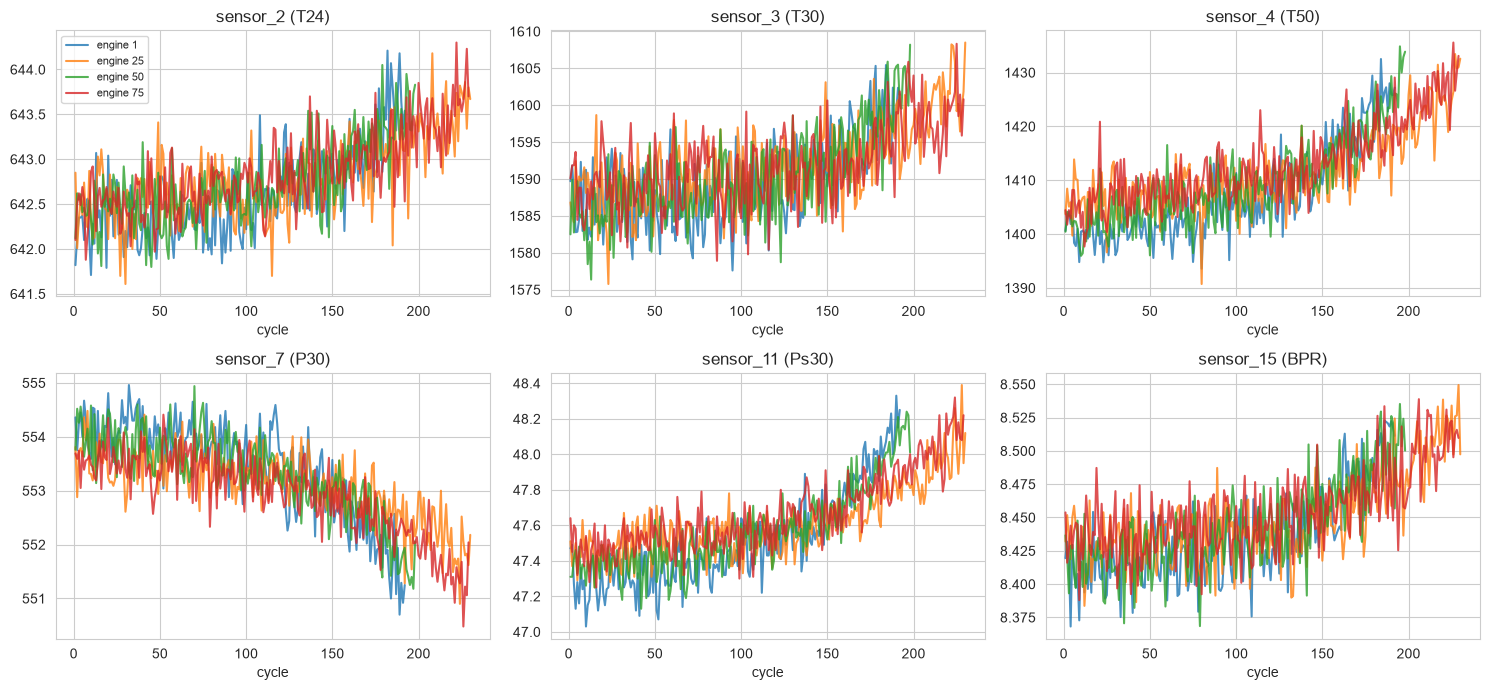

In [6]:
sample_engines = [1, 25, 50, 75]
sensors_to_plot = ["sensor_2", "sensor_3", "sensor_4", "sensor_7", "sensor_11", "sensor_15"]

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.flat, sensors_to_plot):
    for eng in sample_engines:
        g = train[train["unit_number"] == eng]
        ax.plot(g["cycle"], g[col], alpha=0.8, label=f"engine {eng}")
    ax.set_title(f"{col} ({dl.SENSOR_INFO[col]['symbol']})")
    ax.set_xlabel("cycle")
axes[0, 0].legend(fontsize=8)
plt.tight_layout()
plt.show()


## Step 2.5 — Smoothing: raw vs. rolling mean vs. EMA

Sensor noise motivates smoothing before feeding sequences to some models. Comparing raw signal, a trailing rolling mean, and an exponential moving average (EMA) for one engine/sensor makes the trade-off concrete: rolling mean lags less abruptly but needs a full window; EMA reacts faster to recent change with less lag, weighted toward recent cycles.


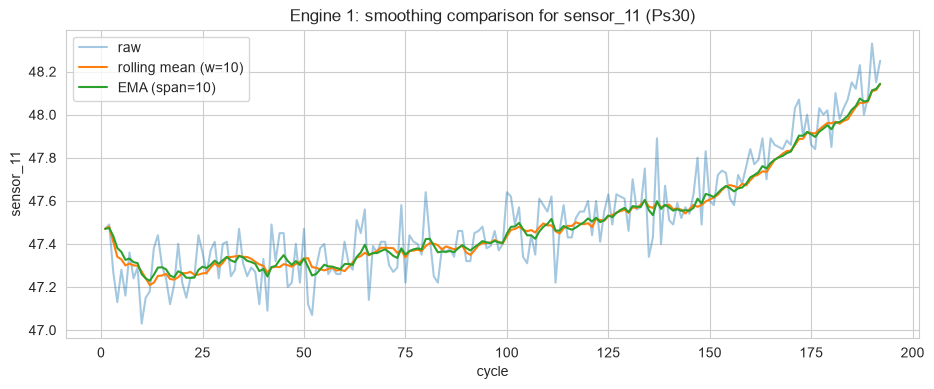

In [7]:
engine_id, sensor_col = 1, "sensor_11"
g = train[train["unit_number"] == engine_id].sort_values("cycle")

raw = g[sensor_col]
rolling_mean = raw.rolling(window=10, min_periods=1).mean()
ema = raw.ewm(span=10, adjust=False).mean()

plt.plot(g["cycle"], raw, alpha=0.4, label="raw")
plt.plot(g["cycle"], rolling_mean, label="rolling mean (w=10)")
plt.plot(g["cycle"], ema, label="EMA (span=10)")
plt.xlabel("cycle")
plt.ylabel(sensor_col)
plt.title(f"Engine {engine_id}: smoothing comparison for {sensor_col} ({dl.SENSOR_INFO[sensor_col]['symbol']})")
plt.legend()
plt.show()


## Step 2.6 — Correlation with RUL and between sensors

Sensor-vs-RUL correlation is a quick (linear-only!) proxy for "how much individual degradation signal does this sensor carry". Sensor-vs-sensor correlation flags redundancy (several C-MAPSS sensors are physically coupled, e.g. temperatures along the gas path).


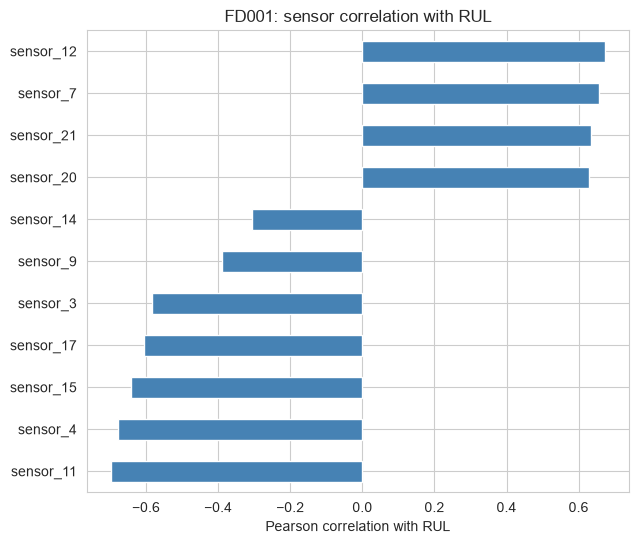

In [8]:
rul_corr = train[variable_sensors + ["RUL"]].corr()["RUL"].drop("RUL").sort_values()
rul_corr.plot(kind="barh", figsize=(7, 6), color="steelblue")
plt.xlabel("Pearson correlation with RUL")
plt.title(f"{SUBSET}: sensor correlation with RUL")
plt.show()


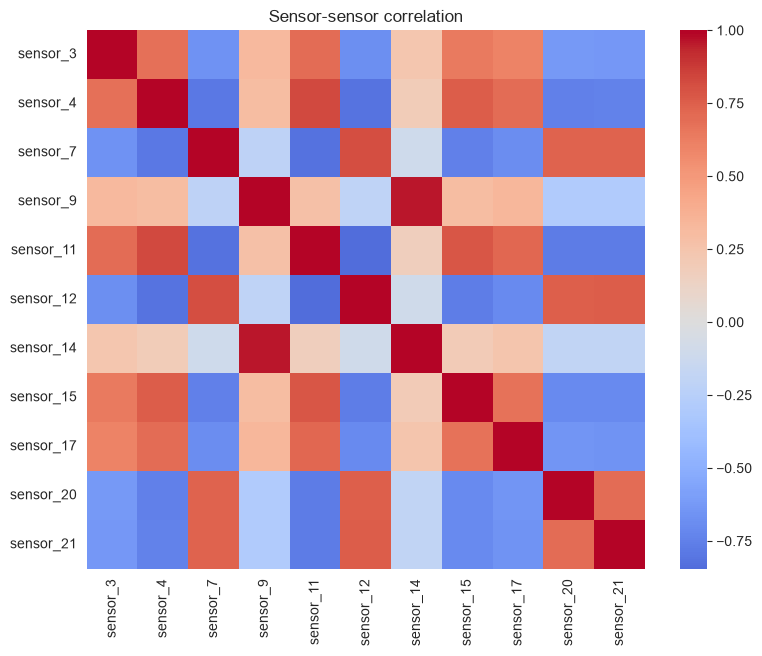

In [9]:
corr_matrix = train[variable_sensors].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False)
plt.title("Sensor-sensor correlation")
plt.show()


**Caveat:** Pearson correlation only captures linear relationships. Several sensors are known (from the paper) to move non-monotonically or non-linearly with wear — tree models and the PCA health indicator we build in `03_feature_engineering.ipynb` are less sensitive to this than a linear-correlation read alone.


## Step 2.7 — Outlier analysis

Flagging (not removing) IQR-based outliers per sensor. In a physically-generated simulation like C-MAPSS, "outliers" are more likely to be genuine transient operating states or late-stage degradation extremes than data errors — so this is diagnostic, not a cleaning step.


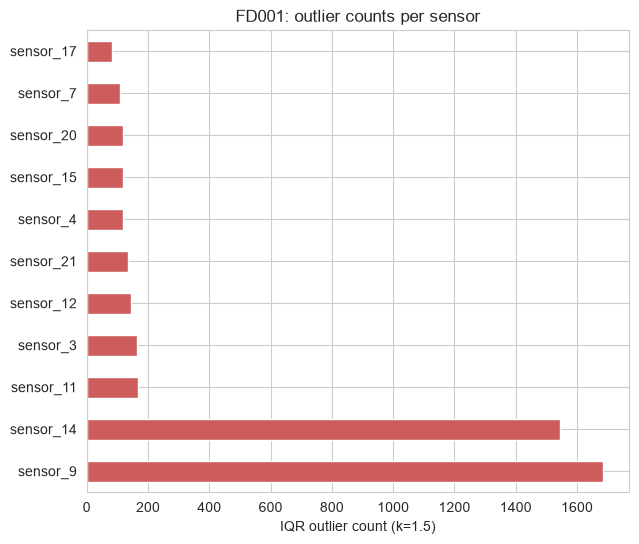

In [10]:
def iqr_outlier_count(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    return int(((series < lo) | (series > hi)).sum())

outlier_counts = pd.Series({col: iqr_outlier_count(train[col]) for col in variable_sensors}).sort_values(ascending=False)
outlier_counts.plot(kind="barh", figsize=(7, 6), color="indianred")
plt.xlabel("IQR outlier count (k=1.5)")
plt.title(f"{SUBSET}: outlier counts per sensor")
plt.show()


## Step 2.8 — Operating-condition effects

FD001 is simulated at a **single** operating condition (sea level), so operational settings should be near-constant here — this is itself a useful confirmation to run. This section becomes far more important for FD002/FD004 (6 operating conditions), where sensor readings shift with flight condition *independently* of degradation and must be normalized per-condition (Phase 4.6 clustering) before degradation trends are comparable across engines.


In [11]:
train[dl.OP_SETTING_COLS].describe()


,op_setting_1,op_setting_2,op_setting_3
count,20631.000000,20631.000000,20631.0
mean,-0.000009,0.000002,100.0
std,0.002187,0.000293,0.0
min,-0.008700,-0.000600,100.0
25%,-0.001500,-0.000200,100.0
50%,0.000000,0.000000,100.0
75%,0.001500,0.000300,100.0
max,0.008700,0.000600,100.0


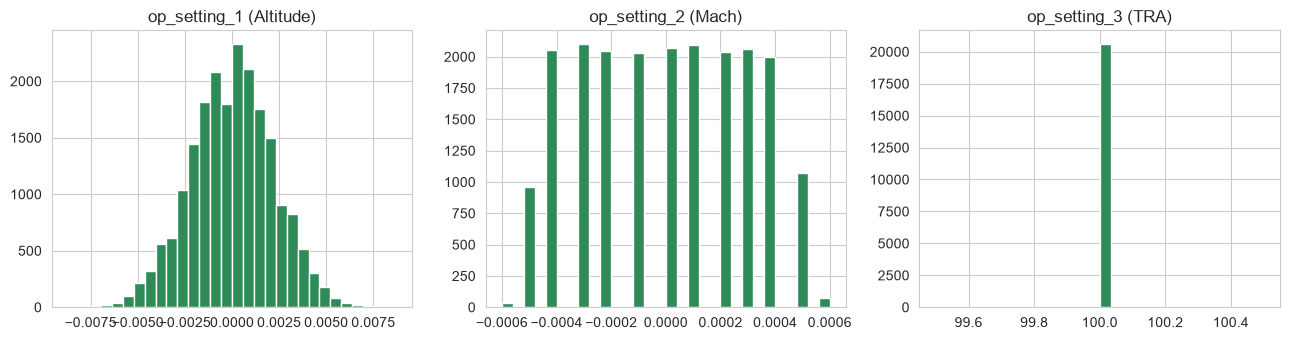

As expected for FD001 (1 operating condition), the settings vary only within tight sensor-noise bands.


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, col in zip(axes, dl.OP_SETTING_COLS):
    ax.hist(train[col], bins=30, color="seagreen")
    ax.set_title(f"{col} ({dl.OP_SETTING_INFO[col]['symbol']})")
plt.tight_layout()
plt.show()
print("As expected for FD001 (1 operating condition), the settings vary only within tight sensor-noise bands.")


## Summary — findings that drive feature engineering

- No missing values / duplicates / infinities in FD001's raw columns.
- Sensor variance triage separates `constant` (safe to drop, zero information), `near_constant`, and `variable` sensors — the exact lists are computed above and will be reused (fit on the train split only) in `03_feature_engineering.ipynb`.
- Several sensors (e.g. `sensor_11`/Ps30, `sensor_4`/T50, `sensor_7`/P30) show clear, strong correlation with RUL and a visibly drifting degradation trend — good candidates for lag/rolling/EMA features.
- Raw sensor noise is non-trivial; rolling-mean and EMA smoothing both suppress it, motivating the rolling/EMA feature set built next.
- FD001 operating settings are effectively constant (single flight condition) — operating-condition clustering is not needed here but will matter for FD002/FD004.

**Next:** `03_feature_engineering.ipynb` — leakage-safe scaling, lag/rolling/diff/EMA features, operating-condition clustering, the PCA-based health indicator, and the engine-grouped train/validation split.
